In [ ]:
pip install pandas numpy tensorflow matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel('Tugas-Kapita Selekta-Bagian2.xlsx', sheet_name='Tugas')
df.columns = ['Time', 'Value']  # Rename columns for simplicity

# Normalisasi data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df['Value'].values.reshape(-1, 1))

# Parameter untuk sliding window
window_size = 5  # Gunakan 5 waktu sebelumnya untuk memprediksi 1 waktu ke depan

# Membuat dataset untuk LSTM
def create_dataset(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled, window_size)

# Reshape X untuk LSTM [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split data menjadi train dan test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
data_scaled

array([[4.63678940e-03],
       [1.95435969e-02],
       [7.76861087e-02],
       [2.87483837e-01],
       [8.19754234e-01],
       [5.90956556e-01],
       [9.66914355e-01],
       [1.27941764e-01],
       [4.47042601e-01],
       [9.88936524e-01],
       [4.37564403e-02],
       [1.68338822e-01],
       [5.60659175e-01],
       [9.85313407e-01],
       [5.78732503e-02],
       [2.19028676e-01],
       [6.84763905e-01],
       [8.63400371e-01],
       [4.71694949e-01],
       [9.96919088e-01],
       [1.22834470e-02],
       [4.95905823e-02],
       [1.89480934e-01],
       [6.14919391e-01],
       [9.47163619e-01],
       [2.00145283e-01],
       [6.40932769e-01],
       [9.20524951e-01],
       [2.92588524e-01],
       [8.28319121e-01],
       [5.68754607e-01],
       [9.81115806e-01],
       [7.40971761e-02],
       [2.75316560e-01],
       [7.98499172e-01],
       [6.43519904e-01],
       [9.17579791e-01],
       [3.02460657e-01],
       [8.44291912e-01],
       [5.25782827e-01],


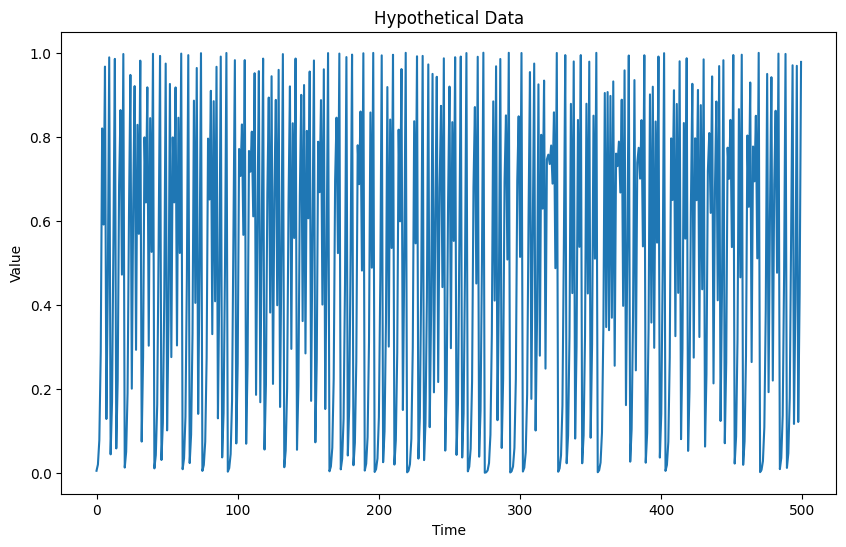

In [ ]:
# Visualisasi hasil
plt.figure(figsize=(10, 6))
plt.plot(df['Value'])
plt.title('Hypothetical Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [ ]:
# Definisikan model LSTM
model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Latih model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.4142 - val_loss: 0.3591
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3181 - val_loss: 0.2715
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2393 - val_loss: 0.1685
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1489 - val_loss: 0.1245
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1331 - val_loss: 0.1229
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1263 - val_loss: 0.1220
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1271 - val_loss: 0.1201
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1208 - val_loss: 0.1196
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1168 - val_loss: 0.1167
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1238 - val_loss: 0.1144
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1163 - val_loss: 0.1125
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

Test Loss: 0.00039626736543141305
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


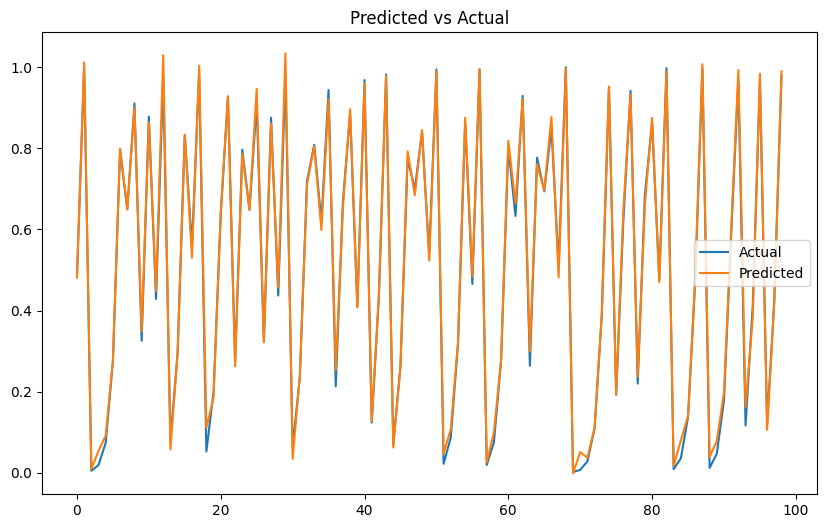

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediksi 20 langkah ke depan:
[[0.07246386]
 [0.26790306]
 [0.8038699 ]
 [0.6385109 ]
 [0.9380906 ]
 [0.29347026]
 [0.8322669 ]
 [0.57574415]
 [1.0204847 ]
 [0.05270071]
 [0.21269202]
 [0.6791974 ]
 [0.894253  ]
 [0.38776317]
 [0.9588737 ]


In [ ]:
# Evaluasi model
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss}")

# Prediksi data uji
y_pred = model.predict(X_test)

# Konversi kembali ke skala asli
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Visualisasi hasil
plt.figure(figsize=(10, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.title('Predicted vs Actual')
plt.show()

# Prediksi 20 langkah ke depan
last_sequence = data_scaled[-window_size:].reshape(1, window_size, 1)
future_predictions = []
for _ in range(20):
    next_pred = model.predict(last_sequence)
    future_predictions.append(next_pred[0, 0])
    # Update last_sequence untuk prediksi berikutnya
    last_sequence = np.append(last_sequence[:, 1:, :], next_pred.reshape(1,1,1), axis=1)

# Konversi prediksi ke skala asli
future_predictions_inv = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Tampilkan prediksi
print("Prediksi 20 langkah ke depan:")
print(future_predictions_inv)

Mean Absolute Error (MAE): 0.3948846924979267
Mean Squared Error (MSE): 0.21432349247429716
Root Mean Squared Error (RMSE): 0.46295085319534424


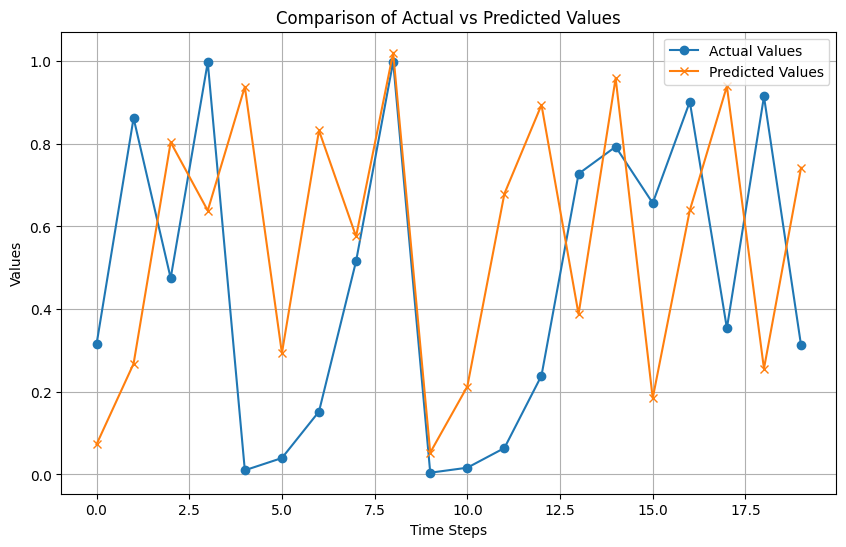

In [ ]:
# Asumsikan 'future_predictions_inv' adalah hasil prediksi 20 langkah ke depan
# Tambahkan nilai aktual
actual_values = np.array([0.3144572, 0.86229547, 0.47496797, 0.99749359, 0.01000052,
                          0.03960202, 0.15213481, 0.51595924, 0.99898121, 0.00407101,
                          0.01621773, 0.06381886, 0.23898407, 0.72748273, 0.79300642,
                          0.65658894, 0.90191961, 0.3538425, 0.91455194, 0.31258675])  # Masukkan nilai aktual Anda di sini
predicted_values = future_predictions_inv.flatten()  # Flatten hasil prediksi

# Perhitungan metrik evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Visualisasi nilai aktual vs prediksi
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(actual_values, label='Actual Values', marker='o')
plt.plot(predicted_values, label='Predicted Values', marker='x')
plt.legend()
plt.title('Comparison of Actual vs Predicted Values')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.grid()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Contoh data
actual_values = np.array([0.3144572, 0.86229547, 0.47496797, 0.99749359, 0.01000052,
                          0.03960202, 0.15213481, 0.51595924, 0.99898121, 0.00407101,
                          0.01621773, 0.06381886, 0.23898407, 0.72748273, 0.79300642,
                          0.65658894, 0.90191961, 0.3538425, 0.91455194, 0.31258675])  # Masukkan nilai aktual
predicted_values = future_predictions_inv.flatten()  # Nilai prediksi dari model

# Perhitungan per elemen
AE = np.abs(actual_values - predicted_values)
SE = (actual_values - predicted_values) ** 2
APE = np.abs((actual_values - predicted_values) / actual_values) * 100

# Metrik evaluasi keseluruhan
MAE = mean_absolute_error(actual_values, predicted_values)
MSE = mean_squared_error(actual_values, predicted_values)
RMSE = np.sqrt(MSE)
MAPE = np.mean(APE)

# Membuat tabel
evaluation_df = pd.DataFrame({
    'Actual Values': actual_values,
    'Predicted Values': predicted_values,
    'Absolute Error (AE)': AE,
    'Squared Error (SE)': SE,
    'Absolute Percentage Error (APE)': APE
})

# Menampilkan tabel dan metrik keseluruhan
print("Evaluation Table:")
print(evaluation_df)

print("\nSummary Metrics:")
print(f"Mean Absolute Error (MAE): {MAE:.4f}")
print(f"Mean Squared Error (MSE): {MSE:.4f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {MAPE:.2f}%")

# Simpan tabel ke file CSV jika diperlukan
evaluation_df.to_csv('evaluation_results.csv', index=False)

Evaluation Table:
    Actual Values  Predicted Values  Absolute Error (AE)  Squared Error (SE)  \
0        0.314457          0.072464             0.241993            0.058561   
1        0.862295          0.267903             0.594392            0.353302   
2        0.474968          0.803870             0.328902            0.108176   
3        0.997494          0.638511             0.358983            0.128869   
4        0.010001          0.938091             0.928090            0.861351   
5        0.039602          0.293470             0.253868            0.064449   
6        0.152135          0.832267             0.680132            0.462580   
7        0.515959          0.575744             0.059785            0.003574   
8        0.998981          1.020485             0.021503            0.000462   
9        0.004071          0.052701             0.048630            0.002365   
10       0.016218          0.212692             0.196474            0.038602   
11       0.063819     